# PyDoseRT inverse planning on a simple water patient

**Author:** Attila Simkó

This example shows how we can optimize a simple treatment plan with PyDoseRT in four steps:

1. Load a reference patient geometry and structure set,
2. Define a machine and beam sequence,
3. Initialize the dose engine and optimization objective,
4. Run beam optimization and monitor the evolving dose distribution.

The goal is to demonstrate a basic inverse-planning workflow with PyDoseRT using a simplified patient-like phantom.

Our goal here was not to **optimize the optimization**. There was no thorough hyperparameter tuning, the number of epochs could possibly be reduced significantly. Instead, here we only show how to use a simple optimization setup with PyDoseRT.

In [1]:
try:
    import pydosert
    print("pydosert is already installed")
except ImportError:
    !pip install pydosert

import numpy as np
import torch
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path
from IPython.display import clear_output

import pydosert as PDRT
from pydosert.utils.plotting import overlay_mask_outline
from pydosert.objectives.losses import dvh_percentile_objective

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

pydosert is already installed


## Load a reference dataset

We use a simple patient-like water phantom with predefined structures.
The dataset contains structure labels that we convert into masks for optimization and visualization.

In [2]:
url = "https://raw.githubusercontent.com/UMU-DDI/PyDoseRT/main/examples/data/water_patient.npz"
local_path = Path("data/water_patient.npz")

# Make sure the folder exists
local_path.parent.mkdir(parents=True, exist_ok=True)

# Download only if the file is missing
if not local_path.exists():
    urllib.request.urlretrieve(url, local_path)
else:
    print(f"{local_path} already exists, skipping download.")

raw_data = np.load(local_path)["structures"]

data/water_patient.npz already exists, skipping download.


## Build the patient and structure masks

Next, we convert the structure labels into binary masks and assemble a `Patient` object.

This gives us:

- a simple CT-like image,
- structure masks for target and organs at risk,
- a convenient container that can be passed to the dose engine.

In [3]:
ct_image = torch.from_numpy(np.where(raw_data != 0.0, 0.0, -1000.0))
external = torch.from_numpy(raw_data > 0.0)
rectum = torch.from_numpy(raw_data == 2.0)
bladder = torch.from_numpy(raw_data == 3.0)
femoralhead_r = torch.from_numpy(raw_data == 4.0)
femoralhead_l = torch.from_numpy(raw_data == 5.0)
ctv = torch.from_numpy(raw_data == 7.0)
ptv = torch.from_numpy(raw_data == 6.0) + ctv

patient = PDRT.Patient(ct_tensor=ct_image, resolution=(2.0, 2.0, 2.0))
patient.add_mask("External", external)
patient.add_mask("Rectum", rectum)
patient.add_mask("Bladder", bladder)
patient.add_mask("FemoralHead_L", femoralhead_l)
patient.add_mask("FemoralHead_R", femoralhead_r)
patient.add_mask("PTV", ptv)
patient.add_mask("CTV", ctv)

colors = {
    "External": "orange",
    "Rectum": "purple",
    "Bladder": "yellow",
    "FemoralHead_L": "green",
    "FemoralHead_R": "blue",
    "PTV": "black",
    "CTV": "red",
}

## Inspect the geometry

Before optimization, it is useful to inspect one slice of the density image together with the structure contours.

This confirms that the target and organs at risk are placed as expected.

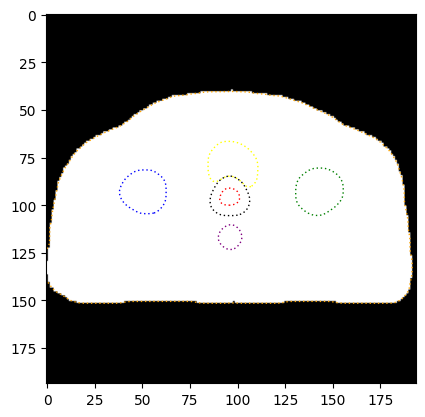

In [4]:
slice_idx = 63
plt.imshow(patient.density_image.cpu().detach().numpy()[slice_idx, :, :], cmap="gray")
for struct_name in patient.structures.keys():
    overlay_mask_outline(
        patient.structures[struct_name].cpu().detach().numpy()[slice_idx, :, :],
        color=colors[struct_name],
    )

## Define the machine, beam sequence, and dose engine

We now set up a simple coplanar beam arrangement together with a machine configuration.

The dose engine uses these inputs together with the patient density to compute dose.
Internally, PyDoseRT uses a differentiable pencil-beam based model, which makes this setup suitable for optimization.

In [5]:
number_of_leaf_pairs = 60

machine_config = PDRT.MachineConfig(
    tpr_20_10=0.739,
    mean_photon_energy_MeV=0.0028538,
    number_of_leaf_pairs=number_of_leaf_pairs,
)

number_of_beams = 40
gantry_angles = torch.from_numpy(np.linspace(-170, 170, number_of_beams, endpoint=False))
field_size = (400, 400)
iso_center = (100.0, 200.0, 200.0)
collimator_angles = torch.from_numpy(np.array([0.0 for _ in range(number_of_beams)]))
sid = 1000.0
open_field_size = 0.0
kernel_size = 15
prescribed_dose = 42.7

beam_sequence = PDRT.BeamSequence.create(
    gantry_angles,
    number_of_leaf_pairs,
    field_size,
    iso_center,
    collimator_angles,
    sid,
    open_field_size,
    device,
    dtype,
    True,
)

patient = patient.to(device).to(dtype)

engine = PDRT.DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=patient.resolution,
    dose_grid_shape=patient.density_image.shape,
    beam_template=beam_sequence,
    kernel_size=kernel_size,
    adjust_values=False,
    dtype=dtype,
    device=device,
)

engine.calibrate(machine_config.calibration_mu, beam_sequence)
engine.train()

ct_volume = patient.density_image.unsqueeze(0)

/home/bolo/Documents/PyDoseRT/src/pydosert/geometry/projections.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  leaf_widths = torch.tensor(


## Define a progress plot

To follow the optimization, we visualize:

- the current dose overlaid on the anatomy,
- cumulative DVH-like curves for all structures.

This makes it easier to see how target coverage and organ sparing evolve during training.

In [6]:
slice_idx = 63
dose_max = 1.1 * prescribed_dose

def plot_progress(epoch, raw_losses, dose_pred):
    plt.figure(figsize=(20, 6))
    plt.suptitle(
        f"Epoch {epoch}: {[str(np.round(loss.item(), 3)) for loss in raw_losses]}",
        fontsize=16,
    )

    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.imshow(patient.density_image.cpu().detach().numpy()[slice_idx, :, :], cmap="gray")
    plt.imshow(
        dose_pred.cpu().detach().numpy()[slice_idx, :, :],
        vmin=0.0,
        vmax=dose_max,
        cmap="jet",
        alpha=0.8,
    )
    for struct_name in patient.structures.keys():
        overlay_mask_outline(
            patient.structures[struct_name].cpu().detach().numpy()[slice_idx, :, :],
            color=colors[struct_name],
        )

    plt.subplot(1, 2, 2)
    for struct_name in patient.structures.keys():
        roi = patient.structures[struct_name]
        dose_values = dose_pred[roi > 0.0].cpu().detach().numpy()
        if dose_values.size == 0:
            continue

        bins = np.linspace(0, dose_max, 1000)
        hist, bin_edges = np.histogram(dose_values, bins=bins, density=False)
        cumulative_hist = np.cumsum(hist[::-1])[::-1]
        cumulative_hist_normalized = np.divide(cumulative_hist, cumulative_hist.max())
        plt.plot(
            bin_edges[:-1],
            cumulative_hist_normalized,
            linestyle="solid",
            label=struct_name,
            color=colors[struct_name],
        )

    clear_output(wait=True)
    plt.show()

## Define the optimization objective

We optimize the beam sequence by balancing a few simple goals:

- deliver the prescribed dose to the PTV,
- reduce high dose to the femoral heads,
- suppress unnecessary dose outside the patient.

Because the PyDoseRT dose calculation is differentiable, these objectives can be optimized directly with gradient-based methods. 

The loss components are currently part of the PyDoseRT package, however we recommend to build your own loss functions for your objectives. These losses are used only for presentation.

In [7]:
patience = 0
epoch = 0
lr = 5.0
num_epochs = 500
lr_decay = 1e-4

optimizer = torch.optim.AdamW(
    beam_sequence.parameters(),
    lr=lr,
    weight_decay=1e-4,
)

last_raw_losses = None
last_dose_pred = None

def closure():
    global last_raw_losses, last_dose_pred

    optimizer.zero_grad(set_to_none=True)

    dose_pred = engine.compute_dose(
        beam_sequence,
        density_image=patient.density_image.unsqueeze(0),
    )
    dose_pred = torch.where(patient.structures["External"], dose_pred[0], 0.0) * 7

    raw_losses = []
    raw_losses.append(
        100.0 * torch.mean(torch.abs(dose_pred[patient.structures["PTV"]] - prescribed_dose) ** 2)
    )
    raw_losses.append(
        dvh_percentile_objective(
            dose_pred, patient.structures["FemoralHead_L"], 20
        )
    )
    raw_losses.append(
        dvh_percentile_objective(
            dose_pred, patient.structures["FemoralHead_R"], 20
        )
    )
    raw_losses.append(
        10.0 * torch.mean(torch.abs(dose_pred[patient.structures["External"]]) ** 2)
    )

    loss = torch.stack(raw_losses).sum()
    loss.backward()

    last_raw_losses = [l.detach().clone() for l in raw_losses]
    last_dose_pred = dose_pred.detach().clone()

    return loss

## Run the optimization

Finally, we iterate the optimizer and inspect the updated dose after each step.

This gives a compact end-to-end example of inverse planning with PyDoseRT.

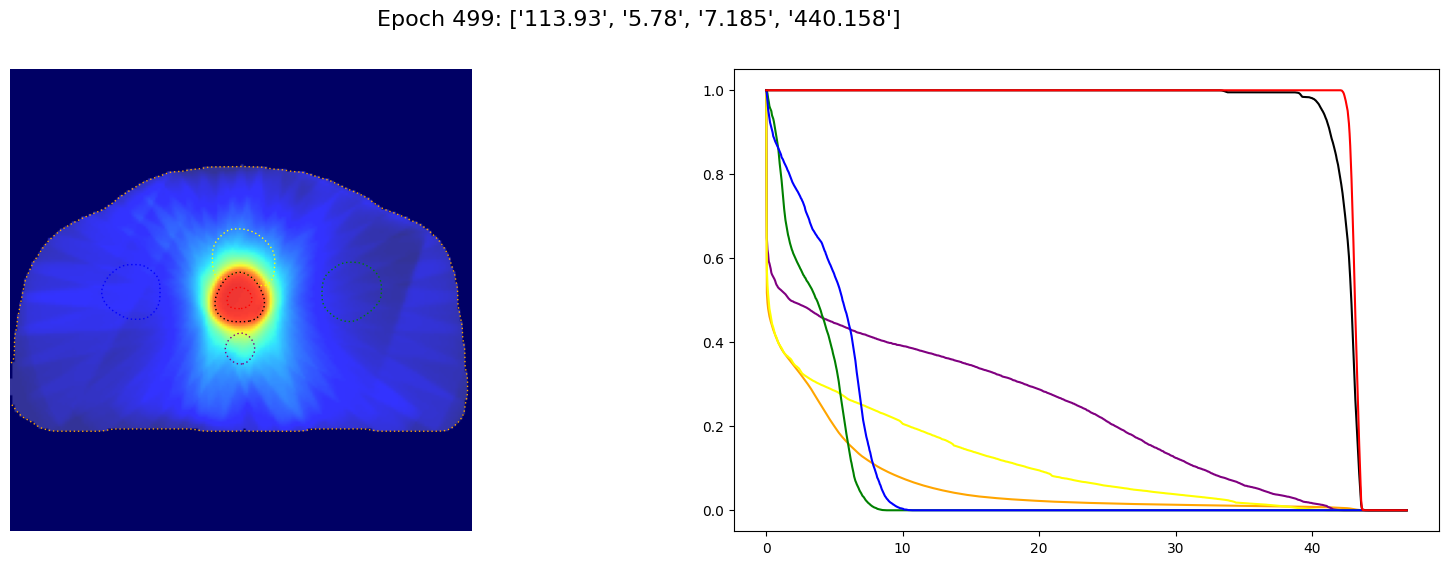

In [8]:
for i in range(num_epochs):
    x = optimizer.step(closure)
    plot_progress(i, last_raw_losses, last_dose_pred)

## Summary

In this example, we used PyDoseRT to optimize a simple multi-beam plan on a patient-like water phantom using differentiable dose calculation and gradient-based updates.